# Forgetting: Why, and Which Kind

A conjugate linear model never forgets. Every observation adds to the
posterior precision, the posterior standard deviation of each coefficient
shrinks like $1/\sqrt{n}$, and after ten thousand rewards the model is as
good as certain. If the world then changes, it takes roughly another ten
thousand rewards to change its mind. Forgetting keeps the posterior from
freezing.

This notebook is about *how* to forget. The simplest rule, scaling the
whole precision matrix by $\gamma$ each step, is what `learning_rate < 1`
and `agent.decay()` do today. It has a classic failure mode, *covariance
windup*, that is easy to hit in bandits, where some arms are pulled far
more often than others. Two
*directional* rules forget only what was observed, and they differ in ways
that matter for both hierarchical and sparse models. The
[math reference](../math/forgetting.rst) has the equations; here we look at
pictures.

We work directly with the posterior precision $\Lambda$ (inverse
covariance) and mean $\theta$, because that is where forgetting acts. One
round of the loop is: forget, then update. Forgetting changes $\Lambda$ and
leaves $\theta$ where it is.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.linalg import cho_factor, cho_solve

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALPHA = 1.0  # prior precision
BETA = 4.0  # noise precision (noise sd 0.5)


def update(R_bar, theta, x, y):
    # Bayesian linear regression update from the forgotten precision R_bar.
    R_new = R_bar + BETA * np.outer(x, x)
    theta_new = cho_solve(cho_factor(R_new), R_bar @ theta + BETA * x * y)
    return R_new, theta_new


def covariance(R):
    return cho_solve(cho_factor(R), np.eye(len(R)))

The four forgetting rules, written out for a dense precision matrix and a
single observation row $x$. Each takes the precision before the update and
returns the precision after forgetting.

| Rule | Formula | What it does to the posterior |
|---|---|---|
| Exponential | $\bar\Lambda = \gamma\Lambda$ | Stretches the uncertainty ellipse uniformly |
| Stabilized | $\bar\Lambda = \gamma\Lambda + (1-\gamma)\alpha I$ | Same stretch, but never past the prior |
| Feature-wise | $\bar\Lambda = D\Lambda D$, $D = \mathrm{diag}(\gamma^{m_i/2})$ | Stretches only the observed coordinates |
| SIFt | $\bar\Lambda = \Lambda - (1-\gamma)\dfrac{\Lambda x x^\top \Lambda}{x^\top\Lambda x}$ | Blurs the posterior along the observed direction |

$m_i$ is the number of rows in which feature $i$ is nonzero, so for one
row it is 1 on the observed features and 0 elsewhere.

In [2]:
def exponential(R, x, gamma):
    return gamma * R


def stabilized(R, x, gamma):
    return gamma * R + (1 - gamma) * ALPHA * np.eye(len(x))


def feature_wise(R, x, gamma):
    d = np.where(x != 0, np.sqrt(gamma), 1.0)
    return d[:, None] * R * d[None, :]


def sift(R, x, gamma):
    w = R @ x
    return R - (1 - gamma) * np.outer(w, w) / (x @ w)


RULES = {
    "exponential": exponential,
    "stabilized": stabilized,
    "feature-wise": feature_wise,
    "SIFt": sift,
}

## Why forget at all?

One arm, one coefficient (its mean reward). The true mean drops from 1.0
to 0.0 halfway through. With no forgetting the posterior has already
collapsed to a needle by then, and the mean crawls toward the new value at
a rate set by how many old observations it has to outvote. With
exponential forgetting at $\gamma = 0.98$, the posterior width settles at a
floor and the mean tracks the change within a few dozen observations.

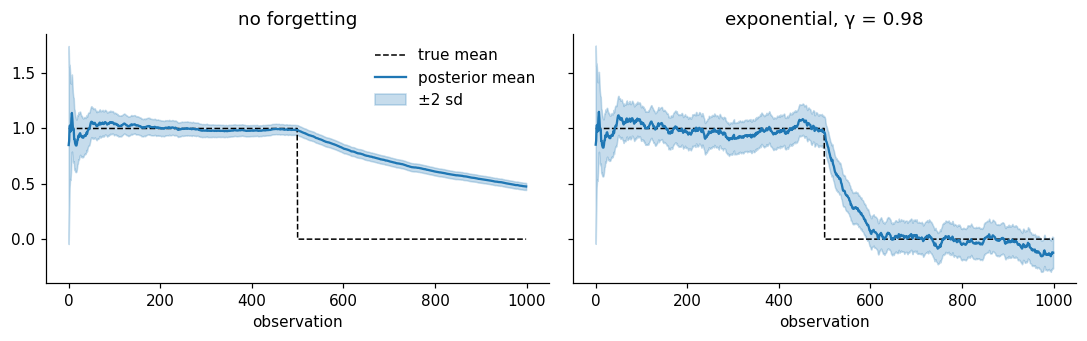

In [3]:
rng = np.random.default_rng(0)
T, SHIFT = 1000, 500
truth = np.where(np.arange(T) < SHIFT, 1.0, 0.0)
rewards = truth + rng.normal(0, 0.5, T)
x1 = np.array([1.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, gamma in zip(axes, [1.0, 0.98]):
    R, theta = ALPHA * np.eye(1), np.zeros(1)
    means, sds = [], []
    for t in range(T):
        R, theta = update(exponential(R, x1, gamma), theta, x1, rewards[t])
        means.append(theta[0])
        sds.append(np.sqrt(covariance(R)[0, 0]))
    means, sds = np.array(means), np.array(sds)
    ax.plot(truth, color="k", lw=1, ls="--", label="true mean")
    ax.plot(means, color="C0", label="posterior mean")
    ax.fill_between(
        np.arange(T),
        means - 2 * sds,
        means + 2 * sds,
        color="C0",
        alpha=0.25,
        label="±2 sd",
    )
    ax.set_title("no forgetting" if gamma == 1.0 else f"exponential, γ = {gamma}")
    ax.set_xlabel("observation")
axes[0].legend(loc="upper right", frameon=False)
plt.tight_layout()

## Covariance windup

Forgetting removes precision; observations put it back. Exponential
forgetting removes it in *every* direction, but an observation only puts
it back along its own row. In a direction the data keeps exciting, the
two balance and the posterior settles at a floor, as in the plot above.
In a direction the data excites rarely or never, nothing balances the
removal: precision decays as $\gamma^t$, the covariance grows as
$\gamma^{-t}$, and the posterior winds up without bound. This is the
covariance windup of the recursive least squares literature, and a
bandit is the ideal place to meet it.

A shared model with an intercept plus a one-hot column per arm, three
arms, and a policy that has settled on arm 0 and pulls it 90% of the
time. Arms 1 and 2 get 5% each. Two directions wind up.

1. **The rare arms.** Arm 1's prediction, intercept plus arm 1, is
   excited one pull in twenty. Between those pulls it loses $1 - \gamma$
   of its precision on each of arm 0's observations, which say nothing
   about it.
2. **The direction no row ever excites.** "Intercept up, all arms down"
   changes no prediction, so no observation row has a component along
   it. Only the prior ever gave it precision, that decays as
   $\alpha\gamma^t$, and the covariance along it grows until the
   Cholesky factorization fails. Every prediction was fine right up to
   the crash, because predictions cannot see this direction.

The directional rules exist to stop windup: forget only what was
excited, so unexcited directions are left alone. We run the same pull
sequence under all four rules with the same $\gamma$ and track two
things: the posterior standard deviation of each arm's predicted reward,
and the posterior variance along the unobservable direction.

In [4]:
rng = np.random.default_rng(1)
T, GAMMA = 2000, 0.98
P_PULL = np.array([0.9, 0.05, 0.05])
ARM_MEANS = np.array([1.0, 0.5, 0.0])
arms = rng.choice(3, size=T, p=P_PULL)
rewards = ARM_MEANS[arms] + rng.normal(0, 0.5, T)


def row(arm):
    x = np.zeros(4)
    x[0] = 1.0
    x[1 + arm] = 1.0
    return x


NULL_DIR = np.array([1.0, -1.0, -1.0, -1.0]) / 2  # orthogonal to every row


def run(rule, gamma=GAMMA):
    R, theta = ALPHA * np.eye(4), np.zeros(4)
    pred_sd = np.full((T, 3), np.nan)
    null_var = np.full(T, np.nan)
    for t in range(T):
        x = row(arms[t])
        try:
            R, theta = update(rule(R, x, gamma), theta, x, rewards[t])
        except np.linalg.LinAlgError:
            print(f"{rule.__name__}: Cholesky failed at observation {t}")
            break
        S = covariance(R)
        pred_sd[t] = [np.sqrt(row(a) @ S @ row(a)) for a in range(3)]
        null_var[t] = NULL_DIR @ S @ NULL_DIR
    return pred_sd, null_var


results = {name: run(rule) for name, rule in RULES.items()}

exponential: Cholesky failed at observation 1575


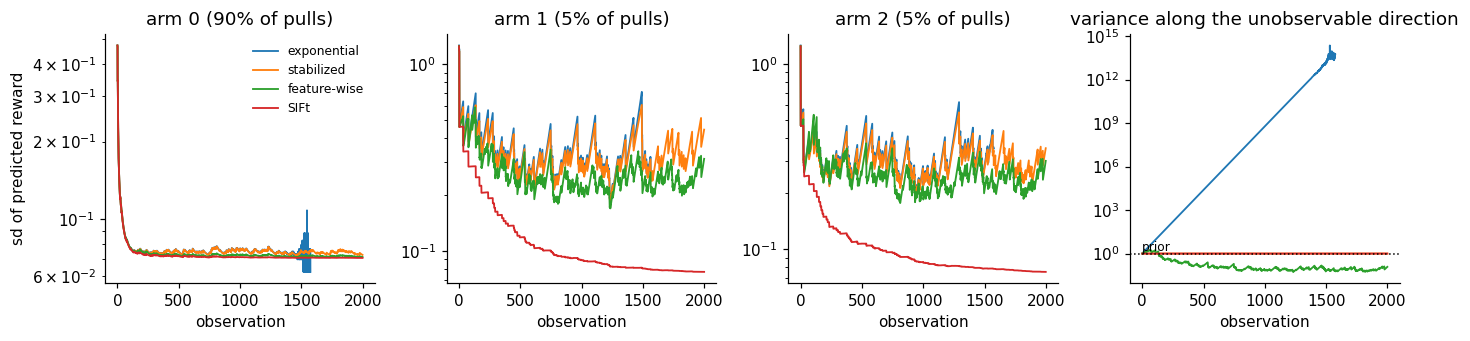

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for a in range(3):
    ax = axes[a]
    for name, (pred_sd, _) in results.items():
        ax.plot(pred_sd[:, a], label=name, lw=1.2)
    ax.set_title(f"arm {a} ({int(P_PULL[a] * 100)}% of pulls)")
    ax.set_ylabel("sd of predicted reward" if a == 0 else "")
    ax.set_xlabel("observation")
    ax.set_yscale("log")
ax = axes[3]
for name, (_, null_var) in results.items():
    ax.plot(null_var, label=name, lw=1.2)
ax.axhline(1 / ALPHA, color="k", ls=":", lw=1)
ax.text(0, 1.4 / ALPHA, "prior", fontsize=8)
ax.set_yscale("log")
ax.set_title("variance along the unobservable direction")
ax.set_xlabel("observation")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

In [6]:
print(f"{'rule':13s} {'pred sd, arms 0/1/2':>24s} {'unobservable variance':>24s}")
for name, (pred_sd, null_var) in results.items():
    last = np.flatnonzero(~np.isnan(null_var))[-1]
    print(
        f"{name:13s} {str(np.round(pred_sd[last], 3)):>24s} {null_var[last]:>24.2g}   (at observation {last})"
    )

rule               pred sd, arms 0/1/2    unobservable variance
exponential        [0.062 0.265 0.354]                  5.4e+13   (at observation 1574)
stabilized         [0.073 0.446 0.351]                        1   (at observation 1999)
feature-wise       [0.071 0.311 0.3  ]                     0.12   (at observation 1999)
SIFt               [0.071 0.077 0.075]                        1   (at observation 1999)


Four different behaviours.

- **Exponential** winds up in both directions. The rare arms' predictions
  widen on the common arm's pulls, and the unobservable direction's
  variance grows by fourteen orders of magnitude until the factorization
  fails partway through the run.
- **Stabilized** caps the windup at the prior. The rare arms are still
  forgotten on arm 0's pulls, just never past $1/\alpha$. This is what the
  empirical Bayes estimators do.
- **SIFt** has no windup at all. The rare arms keep the precision their
  own pulls earned, and the unobservable direction stays at the prior.
- **Feature-wise** has no windup either, but look at the last panel: the
  unobservable direction's variance goes *down*. It ends far tighter than
  the prior, on a direction no observation ever excited. And the rare
  arms' predictions, which should have been left alone, are several times
  wider than under SIFt. These are two views of one event.

### Where the precision came from

Nothing was created. Precision moved. We observed the intercept
constantly, as one half of every row, and feature-wise treats the
intercept coordinate as something that can be forgotten on its own.
Take one arm-1 observation. It taught "intercept plus arm 1 is about
0.5": all of its precision lies along the direction $(1, 0, 1, 0)$ and
none along the unobservable $(1, -1, -1, -1)/2$. Now arm 0 is pulled $k$
times. Feature-wise scales the intercept coordinate of that piece of
information by $\gamma^{k/2}$ and leaves the arm-1 coordinate alone, so
the piece now points along $(\gamma^{k/2}, 0, 1, 0)$. Read that as a
statement: "arm 1, on its own, is about 0.5". That is a claim about how
the total splits between intercept and arm, which is exactly the
unobservable direction, and it is no longer a claim about the sum. The
cell below does the arithmetic for one such piece.

In [7]:
piece = BETA * np.outer(row(1), row(1))  # what one arm-1 observation adds to Λ
SUM_DIR = row(1) / np.sqrt(2)  # "intercept plus arm 1"
D_arm0 = np.diag(np.where(row(0) != 0, np.sqrt(GAMMA), 1.0))  # one arm-0 pull

print(
    f"{'arm-0 pulls since':>18s} {'precision along the sum':>24s} {'along the unobservable':>24s}"
)
for k in [0, 10, 50, 200]:
    Dk = np.linalg.matrix_power(D_arm0, k)
    forgotten = Dk @ piece @ Dk
    print(
        f"{k:>18d} {SUM_DIR @ forgotten @ SUM_DIR:>24.3f} {NULL_DIR @ forgotten @ NULL_DIR:>24.3f}"
    )

 arm-0 pulls since  precision along the sum   along the unobservable
                 0                    8.000                    0.000
                10                    7.250                    0.009
                50                    5.142                    0.157
               200                    2.566                    0.752


Part of what the sum loses is genuinely forgotten. The rest turns into
a claim about the unobservable direction. Over a long run, every one of
the two hundred rare-arm observations has this happen to it, which is
how the unobservable direction ends up with nearly a hundred times the
prior precision. SIFt cannot do this: it forgets along
the direction *the current row* excited, $\Lambda x$ for the arm-0 row,
and adds noise sized by how well that direction is already known. Arm 0
is known very well, so the rare arms barely feel it.

This is not a small-model artefact. It happens whenever a feature shares
rows with features that are observed at very different rates, which is
what hierarchical models are. Drop the intercept and it disappears: with
one-hot columns alone the posterior is uncorrelated and the two
directional rules coincide exactly.

The exponential and stabilized curves for the rare arms are not simply
"wrong" either. Arm 1's uncertainty rising while it is not being pulled
is what makes a Thompson-sampling policy go back and check on it. If
rewards drift with wall-clock time whether or not you observe them, that
is the behaviour you want, and the way to get it safely is to keep
`learning_rate = 1.0` and call `decay()` on a schedule, as the
[decay guide](../howto/decay.rst) recommends.

## Stretch or blur: what the two directional rules do to a posterior

A picture of the mechanism. Two coefficients with posterior correlation
$\rho = 0.8$, and we forget one observation of feature 0 alone,
$x = (1, 0)$, at $\gamma = 0.7$. A large step so the shapes are visible.

- **Exponential** stretches the ellipse uniformly. Every direction gets
  the same factor.
- **Feature-wise** stretches the $\theta_0$ axis only. It multiplies the
  variance of $\theta_0$ by $1/\gamma$, the covariance by
  $1/\sqrt{\gamma}$, and leaves $\theta_1$ alone. The correlation is
  unchanged, so the ellipse keeps its tilt.
- **SIFt** adds noise to $\theta_0$: $\bar\Sigma = \Sigma + q\,x x^\top$
  with $q = \frac{1-\gamma}{\gamma\, x^\top \Lambda x}$. It is the predict
  step of a Kalman filter whose process noise lives only on the observed
  direction. The covariance and $\theta_1$ are untouched, so the ellipse
  gets *wider along $\theta_0$ and less tilted*.

A stretch is multiplicative and keeps the shape. A blur is additive and
changes it.

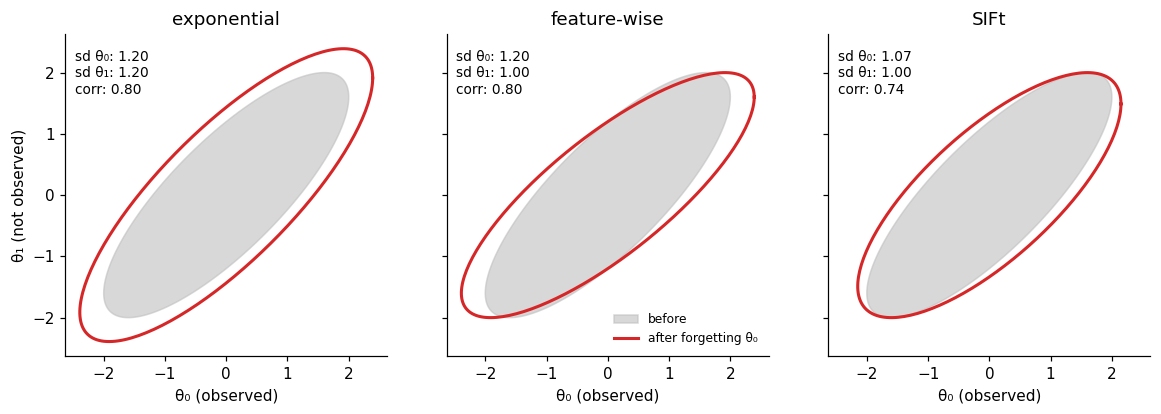

In [8]:
def ellipse(S, n=200):
    t = np.linspace(0, 2 * np.pi, n)
    pts = 2 * np.linalg.cholesky(S) @ np.stack([np.cos(t), np.sin(t)])
    return pts[0], pts[1]


RHO, GAMMA_2D = 0.8, 0.7
Sigma = np.array([[1.0, RHO], [RHO, 1.0]])
Lam = np.linalg.inv(Sigma)
x0 = np.array([1.0, 0.0])
GEOMETRY = ["exponential", "feature-wise", "SIFt"]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, name in zip(axes, GEOMETRY):
    S_bar = np.linalg.inv(RULES[name](Lam, x0, GAMMA_2D))
    ax.fill(*ellipse(Sigma), color="0.75", alpha=0.6, label="before")
    ax.plot(*ellipse(S_bar), color="C3", lw=2, label="after forgetting θ₀")
    ax.set_title(name)
    ax.set_xlabel("θ₀ (observed)")
    ax.set_aspect("equal")
    corr = S_bar[0, 1] / np.sqrt(S_bar[0, 0] * S_bar[1, 1])
    ax.text(
        0.03,
        0.95,
        f"sd θ₀: {np.sqrt(S_bar[0, 0]):.2f}\nsd θ₁: {np.sqrt(S_bar[1, 1]):.2f}\ncorr: {corr:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
    )
axes[0].set_ylabel("θ₁ (not observed)")
axes[1].legend(loc="lower right", frameon=False, fontsize=8)
plt.tight_layout()

### What each one gives up

Both directional rules leave the marginal of $\theta_1$ alone, and they
coincide exactly when $\theta_0$ and $\theta_1$ are uncorrelated in the
posterior. With correlation they make different promises.

**SIFt is a proper Bayesian step.** "The coefficient I observed may have
moved since; add noise to it." Every direction gets wider or stays the
same, never narrower. That is what the Kalman predict step guarantees,
and it is why SIFt can be applied for as long as you like without the
posterior drifting somewhere strange.

**Feature-wise is a tempering step.** "Discount everything I know about
$\theta_0$ by $\gamma$, but keep the shape of the joint." Keeping the
tilt has a cost: in a band of mixed directions the posterior gets
slightly *narrower*, which no forgetting step should do. It is the
same leak that tightened the unobservable direction in the bandit
example, seen one step at a time. The plot below shows the posterior
standard deviation in every direction of the plane, before and after
each rule. Feature-wise dips below the "before" curve; SIFt never does.

feature-wise, worst direction: sd ratio after/before = 0.943 at 114°


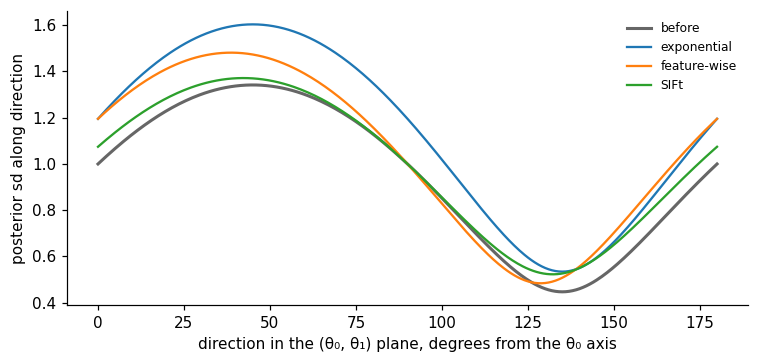

In [9]:
angles = np.linspace(0, np.pi, 361)
U = np.stack([np.cos(angles), np.sin(angles)])


def sd_by_direction(S):
    return np.sqrt(np.einsum("ij,ik,kj->j", U, S, U))


fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(np.degrees(angles), sd_by_direction(Sigma), color="0.4", lw=2, label="before")
for name in GEOMETRY:
    S_bar = np.linalg.inv(RULES[name](Lam, x0, GAMMA_2D))
    ax.plot(np.degrees(angles), sd_by_direction(S_bar), lw=1.5, label=name)
ax.set_xlabel("direction in the (θ₀, θ₁) plane, degrees from the θ₀ axis")
ax.set_ylabel("posterior sd along direction")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

S_fw = np.linalg.inv(feature_wise(Lam, x0, GAMMA_2D))
ratio = sd_by_direction(S_fw) / sd_by_direction(Sigma)
print(
    f"feature-wise, worst direction: sd ratio after/before = {ratio.min():.3f} "
    f"at {np.degrees(angles[ratio.argmin()]):.0f}°"
)

How much this matters depends on how correlated the features are and how
hard you forget. At the $\gamma = 0.7$ used for the pictures the dip is
noticeable. At a realistic per-observation $\gamma$ it is small unless
features are strongly correlated:

In [10]:
print("worst-direction sd ratio for feature-wise, one observation of θ₀")
print(f"{'':>8s}" + "".join(f"ρ={r:<7}" for r in [0.5, 0.8, 0.95, 0.99]))
for g in [0.98, 0.9, 0.7]:
    line = f"γ={g:<5} "
    for r in [0.5, 0.8, 0.95, 0.99]:
        S = np.array([[1.0, r], [r, 1.0]])
        S_fw = np.linalg.inv(feature_wise(np.linalg.inv(S), x0, g))
        line += f"{(sd_by_direction(S_fw) / sd_by_direction(S)).min():<9.3f}"
    print(line)

worst-direction sd ratio for feature-wise, one observation of θ₀
        ρ=0.5    ρ=0.8    ρ=0.95   ρ=0.99   
γ=0.98  0.999    0.997    0.989    0.970    
γ=0.9   0.996    0.983    0.944    0.853    
γ=0.7   0.986    0.943    0.825    0.602    


So far SIFt looks like the safer rule. Its cost is structural.

## The cost: SIFt fills in sparse models

For a sparse model, the precision matrix has a nonzero wherever two
features have appeared in the same row. With an intercept plus one-hot
columns for arms and arm-by-segment cells, that pattern is a star: the
intercept touches everything, each arm touches its cells, and the cells
touch nothing else. It stays sparse no matter how many observations
arrive, and the sparse Cholesky factor stays cheap.

Exponential, stabilized and feature-wise forgetting scale entries of
$\Lambda$ in place, so the pattern never changes. SIFt subtracts a
rank-one matrix $\Lambda x x^\top \Lambda$. The vector $\Lambda x$ is
nonzero on every feature that shares a row with the observed ones, and
with a shared intercept that is *every feature seen so far*. Each SIFt
step therefore writes a dense block over everything the model has ever
seen, and after a few hundred observations the precision matrix is
dense.

The rules in `bayesianbandits._forgetting` are the sparse-aware versions
used by the estimators. We run them on a model with one intercept, 50
arms, and 10 segments per arm, and count the nonzeros in $\Lambda$ after
each observation.

exponential   nnz after 400 observations:    1767  (0.6% dense)
feature-wise  nnz after 400 observations:    1767  (0.6% dense)
SIFt          nnz after 400 observations:  109121  (35.9% dense)


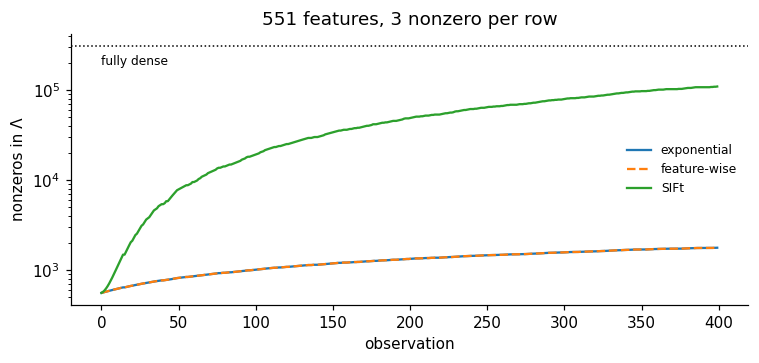

In [11]:
from bayesianbandits._forgetting import (
    ExponentialForgetting,
    FeatureWiseForgetting,
    SiftForgetting,
)

N_ARMS, N_SEG = 50, 10
P = 1 + N_ARMS + N_ARMS * N_SEG
rng = np.random.default_rng(2)


def sparse_row(arm, seg):
    cols = [0, 1 + arm, 1 + N_ARMS + arm * N_SEG + seg]
    return sparse.csc_array((np.ones(3), ([0, 0, 0], cols)), shape=(1, P))


T_SPARSE = 400
draws = [(rng.integers(N_ARMS), rng.integers(N_SEG)) for _ in range(T_SPARSE)]
sparse_rules = {
    "exponential": ExponentialForgetting(),
    "feature-wise": FeatureWiseForgetting(),
    "SIFt": SiftForgetting(eps=1e-10),
}
nnz = {}
for name, rule in sparse_rules.items():
    R = sparse.csc_array(ALPHA * sparse.eye(P))
    counts = []
    for arm, seg in draws:
        X = sparse_row(arm, seg)
        R_bar, _, _ = rule(R, X, np.zeros(1), GAMMA)
        R = sparse.csc_array(R_bar + BETA * (X.T @ X))
        R.eliminate_zeros()
        counts.append(R.nnz)
    nnz[name] = np.array(counts)

fig, ax = plt.subplots(figsize=(7, 3.4))
for name, counts in nnz.items():
    ax.plot(counts, label=name, lw=1.5, ls="--" if name == "feature-wise" else "-")
ax.axhline(P * P, color="k", ls=":", lw=1)
ax.text(0, P * P * 0.8, "fully dense", fontsize=8, va="top")
ax.set_yscale("log")
ax.set_xlabel("observation")
ax.set_ylabel("nonzeros in Λ")
ax.set_title(f"{P} features, 3 nonzero per row")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
for name, counts in nnz.items():
    print(
        f"{name:13s} nnz after {T_SPARSE} observations: {counts[-1]:>7d}  ({counts[-1] / P**2:.1%} dense)"
    )

The exponential and feature-wise curves lie on top of each other: the
pattern is whatever the data made it. SIFt's curve tracks the square of
the number of features seen so far, and at this size it is a third of
the way to dense within a few hundred observations. At a million
features, which is where the sparse estimators are meant to operate,
that is not a slowdown but a memory failure. This is why the library
treats SIFt as a dense-only rule and feature-wise as the directional
rule for sparse models.

## Choosing

| | Forgets | Sparsity | Watch out for |
|---|---|---|---|
| **Exponential** | everything, every step | preserved | prior collapse on unobserved directions; rare arms forgotten by common ones |
| **Stabilized** | everything, down to the prior floor | preserved | rare arms still forgotten by common ones; used by the empirical Bayes estimators |
| **Feature-wise** | the observed coordinates | preserved | no windup, but precision leaks from shared features' sums into unexcited directions; rare arms widen, unobservable directions tighten |
| **SIFt** | what the observed rows taught, as added noise | destroyed | dense fill-in; dense models only |

Three practical notes.

**The same $\gamma$ means different amounts of forgetting.** One
exponential step removes a fraction $1-\gamma$ of the precision in all
$p$ directions. A feature-wise step removes it in the $k$ observed
coordinates, and a SIFt step along one direction. If you switch rules and
want the same total rate of forgetting, expect to retune $\gamma$; a
rough conversion for a row with $k$ nonzeros is
$\gamma_{\text{sift}} \approx \gamma_{\text{fw}}^{\,k}$.

**Shared features are where the directional rules part ways.** With
one-hot arm columns and no intercept the two coincide, and feature-wise
is exact. Add a shared level, and feature-wise widens the rare arms'
predictions well beyond SIFt, though still without windup.

**Time-based or observation-based?** Directional rules forget an arm
only when it is observed. If rewards drift over time regardless, an arm
that is never pulled keeps a stale, confident posterior. Exponential
`decay()` on a schedule is the tool for that, and the two can be combined:
directional forgetting per update to keep the precision well conditioned,
and a slower scheduled decay to keep stale arms honest.